<a href="https://colab.research.google.com/github/sruthi-kurra/fraud-detection-gnn/blob/main/01_data_loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Install Kaggle & upload credentials

In [2]:
from google.colab import files
uploaded = files.upload()  # click Browse and select the zip file

import zipfile
with zipfile.ZipFile('ieee-fraud-detection.zip', 'r') as z:
    z.extractall('data/')

print("Done!")

Saving ieee-fraud-detection.zip to ieee-fraud-detection.zip
Done!


## Cell 2 — Load & merge transaction data

In [3]:
import pandas as pd
import numpy as np

train_txn = pd.read_csv('data/train_transaction.csv')
train_id  = pd.read_csv('data/train_identity.csv')

df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
df.head()

Shape: (590540, 434)
Fraud rate: 3.50%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## Cell 3 — Explore the data (EDA)

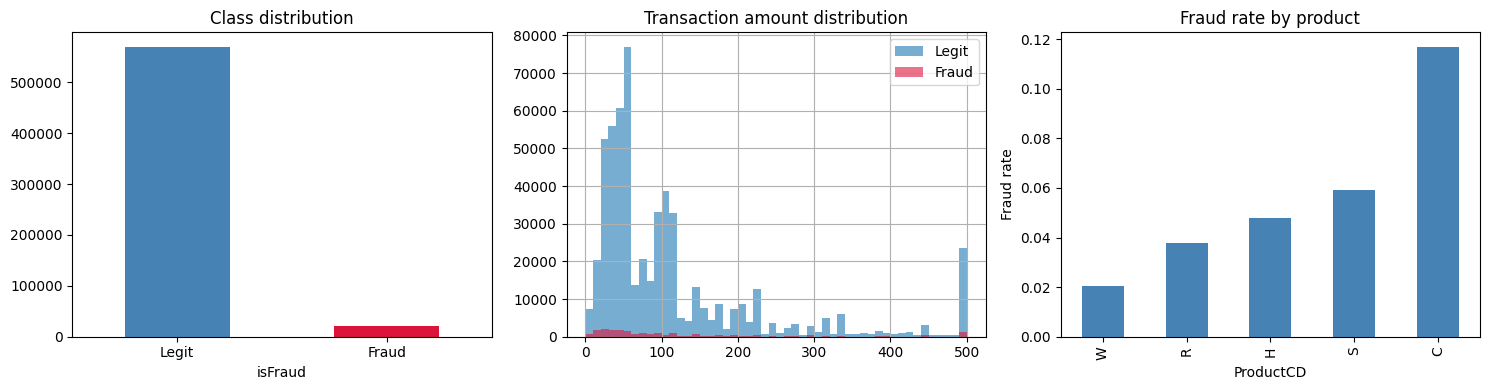

Unique accounts (card1): 13553
Columns: 434


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud distribution
df['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Class distribution')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# Transaction amounts
df[df['isFraud']==0]['TransactionAmt'].clip(0,500).hist(bins=50, ax=axes[1], alpha=0.6, label='Legit')
df[df['isFraud']==1]['TransactionAmt'].clip(0,500).hist(bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='crimson')
axes[1].set_title('Transaction amount distribution')
axes[1].legend()

# Fraud rate by product
df.groupby('ProductCD')['isFraud'].mean().sort_values().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Fraud rate by product')
axes[2].set_ylabel('Fraud rate')

plt.tight_layout()
plt.savefig('eda.png')   # saves for later use in README
plt.show()

print(f"Unique accounts (card1): {df['card1'].nunique()}")
print(f"Columns: {df.shape[1]}")

## Cell 4 — Clean & save for next notebook

In [5]:
core_cols = [
    'TransactionID', 'TransactionDT', 'TransactionAmt',
    'card1', 'card4', 'ProductCD',
    'P_emaildomain', 'R_emaildomain',
    'addr1', 'isFraud'
]

df_clean = df[core_cols].copy()

df_clean['addr1']          = df_clean['addr1'].fillna(-1)
df_clean['P_emaildomain']  = df_clean['P_emaildomain'].fillna('unknown')
df_clean['R_emaildomain']  = df_clean['R_emaildomain'].fillna('unknown')
df_clean['card4']          = df_clean['card4'].fillna('unknown')
df_clean['TransactionAmt'] = df_clean['TransactionAmt'].fillna(df_clean['TransactionAmt'].median())

df_clean.to_csv('data/clean_transactions.csv', index=False)
print(f"Saved! Shape: {df_clean.shape}")
df_clean.head()

Saved! Shape: (590540, 10)


,TransactionID,TransactionDT,TransactionAmt,card1,card4,ProductCD,P_emaildomain,R_emaildomain,addr1,isFraud
0,2987000,86400,68.5,13926,discover,W,unknown,unknown,315.0,0
1,2987001,86401,29.0,2755,mastercard,W,gmail.com,unknown,325.0,0
2,2987002,86469,59.0,4663,visa,W,outlook.com,unknown,330.0,0
3,2987003,86499,50.0,18132,mastercard,W,yahoo.com,unknown,476.0,0
4,2987004,86506,50.0,4497,mastercard,H,gmail.com,unknown,420.0,0
